In [2]:
# xarray to read NETCDF
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
CanESM5 = xr.open_mfdataset('data/NMME/CanESM5/prec/*.nc')
CanESM5 = CanESM5.assign_coords(X=(((CanESM5.X + 180) % 360) - 180))
CanESM5.sortby(CanESM5['X'])
CanESM5_south_sudan_M1 = (CanESM5.sel(Y=slice(3.5, 12.5), X=slice(25, 35))
                       .rename({'Y': 'latitude', 'X': 'longitude', 'prec': 'predicted precip', 'S': 'date of prediction', 'L': 'lead time'})
                       .where(CanESM5['M'] == 1, drop = True))
CanESM5_south_sudan_M1

AttributeError: 'NoneType' object has no attribute 'render'

<xarray.Dataset> Size: 2MB
Dimensions:             (date of prediction: 366, lead time: 12, M: 1,
                         latitude: 9, longitude: 11)
Coordinates:
  * lead time           (lead time) float32 48B 0.5 1.5 2.5 ... 9.5 10.5 11.5
  * latitude            (latitude) float32 36B 4.0 5.0 6.0 ... 10.0 11.0 12.0
  * M                   (M) float32 4B 1.0
  * date of prediction  (date of prediction) datetime64[ns] 3kB 1991-01-01 .....
  * longitude           (longitude) float32 44B 25.0 26.0 27.0 ... 34.0 35.0
Data variables:
    predicted precip    (date of prediction, lead time, M, latitude, longitude) float32 2MB dask.array<chunksize=(1, 12, 1, 9, 11), meta=np.ndarray>

In [ ]:
CanESM5_south_sudan_df = CanESM5_south_sudan
CanESM5_south_sudan_df['time'] = CanESM5_south_sudan_df.apply(lambda x: x['date of prediction'] + pd.DateOffset(months=int(x['lead time'])), axis=1)
CanESM5_south_sudan_df

TypeError: <lambda>() got an unexpected keyword argument 'axis'

In [12]:
chirps = xr.open_dataset('data/CHIRPS/chirps-v2.0.monthly.nc')


In [8]:
chirps_south_sudan_df = chirps_south_sudan.to_dataframe().reset_index()
chirps_south_sudan_df

,time,latitude,longitude,precip
0,1991-01-01,4.0,25.0,16.176336
1,1991-01-01,4.0,26.0,22.078163
2,1991-01-01,4.0,27.0,14.702608
3,1991-01-01,4.0,28.0,22.659842
4,1991-01-01,4.0,29.0,22.823318
...,...,...,...,...
1183,1991-12-01,12.0,31.0,0.166143
1184,1991-12-01,12.0,32.0,0.061604
1185,1991-12-01,12.0,33.0,0.082613
1186,1991-12-01,12.0,34.0,0.105609


In [9]:
CanESM5_south_sudan_df_clean = CanESM5_south_sudan_df.merge(chirps_south_sudan_df, on = ['latitude', 'longitude', 'time'], how = 'left').drop(['time', 'latitude', 'longitude'], axis = 1)
CanESM5_south_sudan_df_clean['month'] = CanESM5_south_sudan_df_clean['date of prediction'].dt.month
corr_clean = CanESM5_south_sudan_df_clean.drop('date of prediction', axis = 1).groupby(['month', 'lead time']).corr(method='pearson').drop('precip', axis = 1).droplevel(level=2).reset_index()
corr_clean_1 = corr_clean.drop(corr_clean.index[::2])
corr_clean_1['predicted precip'] = corr_clean_1['predicted precip']
corr_clean_1

,month,lead time,predicted precip
1,1,0.5,0.811742
3,1,1.5,0.912284
5,1,2.5,0.886696
7,1,3.5,0.837231
9,1,4.5,0.773618
...,...,...,...
279,12,7.5,NaN
281,12,8.5,NaN
283,12,9.5,NaN
285,12,10.5,NaN


In [10]:
stat = (CanESM5_south_sudan_df_clean.drop('date of prediction', axis = 1)
        .groupby(['month', 'lead time']).agg(['mean', 'std']).reset_index())
stat.columns = stat.columns.droplevel()
stat.columns = ['month', 'lead time', 'pred mean', 'pred std', 'actual mean', 'actual std']
stat_clean = stat.merge(corr_clean_1.reset_index(), on = ['month', 'lead time'], how = 'left').drop("index", axis = 1)
stat_clean.columns = ['month', 'lead time', 'pred mean', 'pred std', 'actual mean', 'actual std', 'corr']
stat_clean['conditional bias'] = stat_clean.apply(lambda x: np.power(x['corr'] - x['pred std']/x['actual std'],2), axis = 1)
stat_clean['unconditional bias'] = stat_clean.apply(lambda x: np.power((x['pred mean'] - x['actual mean'])/x['actual std'],2), axis = 1)
stat_clean['potential skill'] = stat_clean.apply(lambda x: np.power(x['corr'],2), axis = 1)
stat_clean = stat_clean.drop(['corr','pred mean', 'pred std', 'actual mean', 'actual std'], axis = 1)
stat_clean['skill score'] = stat_clean.apply(lambda x: x['potential skill'] - x['conditional bias'] - x['unconditional bias'], axis = 1)
stat_clean

,month,lead time,conditional bias,unconditional bias,potential skill,skill score
0,1,0.5,0.591124,0.300686,0.658925,-0.232884
1,1,1.5,0.771972,0.427922,0.832262,-0.367632
2,1,2.5,0.718501,0.694609,0.786230,-0.626880
3,1,3.5,0.656288,1.165631,0.700955,-1.120964
4,1,4.5,0.551392,5.283461,0.598484,-5.236369
...,...,...,...,...,...,...
139,12,7.5,NaN,NaN,NaN,NaN
140,12,8.5,NaN,NaN,NaN,NaN
141,12,9.5,NaN,NaN,NaN,NaN
142,12,10.5,NaN,NaN,NaN,NaN


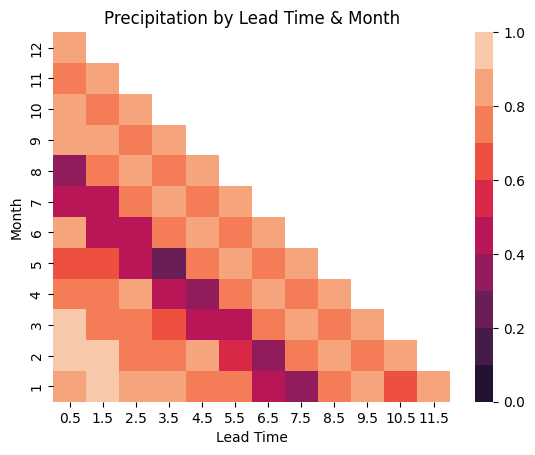

In [11]:
pivot_df = corr_clean_1.pivot_table(index = 'month', columns = 'lead time', values = 'predicted precip')
colormap = sns.color_palette('rocket', 10)
ax = sns.heatmap(pivot_df, vmin=0, vmax=1, cmap = colormap)
ax.invert_yaxis()
plt.title("Precipitation by Lead Time & Month")
plt.ylabel("Month")
plt.xlabel("Lead Time")
plt.show()

In [13]:
CanESM5_eastern_east_africa = (CanESM5.sel(Y=slice(-3.5, 8), X=slice(38, 50))
                               .rename(
    {'Y': 'latitude', 'X': 'longitude', 'prec': 'predicted precip', 'S': 'date of prediction', 'L': 'lead time'}))

# Interpolate and subset CHIRPS to match spatial resolution of CanESM5
chirps_eastern_east_africa = (chirps.sel(latitude=slice(-3.5, 9), longitude=slice(37,
                                                                                  51))  # One degree of resolution must be added for interpolation
                              .interp_like(CanESM5_eastern_east_africa, method='nearest'))

# Calculate realized dates for CanESM5, convert to dataframe
CanESM5_eastern_east_africa_df = CanESM5_eastern_east_africa.to_dataframe().reset_index()
CanESM5_eastern_east_africa_df['realization_time'] = CanESM5_eastern_east_africa_df.apply(
    lambda x: x['date of prediction'] + pd.DateOffset(months=int(x['lead time'])), axis=1)

# Convert CHIRPS to dataframe
chirps_eastern_east_africa_df = chirps_eastern_east_africa.to_dataframe().reset_index()

# Merge CHIRPS and CanESM5 dataframe
eastern_east_africa_merged_df = CanESM5_eastern_east_africa_df.merge(chirps_eastern_east_africa_df, how='left',
                                                                     left_on=['realization_time', 'latitude',
                                                                              'longitude'],
                                                                     right_on=['time', 'latitude',
                                                                               'longitude']).dropna()

# Save to .csv
eastern_east_africa_merged_df.to_csv('data/csv/eastern_east_africa_CanESM5_merged.csv')

# Drop date of prediction, latitude, longitude
eastern_east_africa_merged_df = eastern_east_africa_merged_df.drop(
    columns=['date of prediction', 'latitude', 'longitude'])
# make a new column month that extracts month from realization time
eastern_east_africa_merged_df['month'] = eastern_east_africa_merged_df['realization_time'].dt.month

# Make calculations on the merged dataframe for plotting
corr_clean = eastern_east_africa_merged_df.drop(['realization_time', 'time'], axis=1).groupby(
    ['month', 'lead time', 'M']).corr(method='pearson').drop('precip', axis=1).droplevel(level=3).reset_index()
corr_clean_1 = corr_clean.drop(corr_clean.index[::2])

stat_eastern_east_africa = (eastern_east_africa_merged_df.drop(['realization_time', 'time'], axis=1)
                            .groupby(['month', 'lead time', 'M']).agg(['mean', 'std']).reset_index())
stat_eastern_east_africa.columns = stat_eastern_east_africa.columns.droplevel()
stat_eastern_east_africa.columns = ['month', 'lead time', 'M', 'pred mean', 'pred std', 'actual mean', 'actual std']
stat_eastern_east_africa_clean = stat_eastern_east_africa.merge(corr_clean_1.reset_index(),
                                                                on=['month', 'lead time', 'M'], how='left').drop(
    "index", axis=1)
stat_eastern_east_africa_clean.columns = ['month', 'lead time', 'M', 'pred mean', 'pred std', 'actual mean',
                                          'actual std', 'corr']
stat_eastern_east_africa_clean['conditional bias'] = stat_eastern_east_africa_clean.apply(
    lambda x: np.power(x['corr'] - x['pred std'] / x['actual std'], 2), axis=1)
stat_eastern_east_africa_clean['unconditional bias'] = stat_eastern_east_africa_clean.apply(
    lambda x: np.power((x['pred mean'] - x['actual mean']) / x['actual std'], 2), axis=1)
stat_eastern_east_africa_clean['potential skill'] = stat_eastern_east_africa_clean.apply(
    lambda x: np.power(x['corr'], 2), axis=1)
stat_eastern_east_africa_clean = stat_eastern_east_africa_clean.drop(
    ['corr', 'pred mean', 'pred std', 'actual mean', 'actual std'], axis=1)
stat_eastern_east_africa_clean['skill score'] = stat_eastern_east_africa_clean.apply(
    lambda x: x['potential skill'] - x['conditional bias'] - x['unconditional bias'], axis=1)
stat_eastern_east_africa_clean = stat_eastern_east_africa_clean.groupby(['month', 'lead time']).mean().drop('M',
                                                                                                            axis=1).reset_index()
stat_eastern_east_africa_clean['region'] = 'Eastern East Africa'

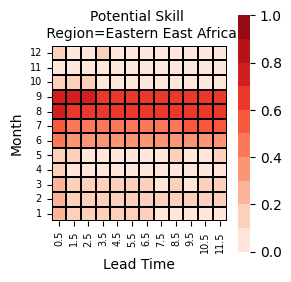

In [14]:
def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    d = data.pivot(index=args[1], columns=args[0], values=args[2])
    sns.heatmap(d, **kwargs, vmin=0, vmax=1, 
                cmap=sns.color_palette('Reds', 10),
                linewidths=0.1, linecolor='black')
    plt.xticks(np.arange(0.5, 12.5, 1))  # Set xticks explicitly
    plt.gca().set_xticklabels(np.arange(0.5, 12.5, 1))  # Set xticklabels
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    plt.gca().invert_yaxis()

fg = sns.FacetGrid(stat_eastern_east_africa_clean, col='region', sharex=False, sharey=False)
fg.map_dataframe(draw_heatmap, 'lead time', 'month', 'potential skill', square = True)

fg.set_titles('Potential Skill \n Region={col_name}')
fg.set_ylabels("Month")
fg.set_xlabels("Lead Time")
plt.show()
fg.savefig('figures/potential_skill.png')